In [1]:
import numpy as np
from matplotlib import pyplot as plt
from plt_func import plt_hs

(100, 512)
Num of time cells: 4
Interval length (s): 0.5


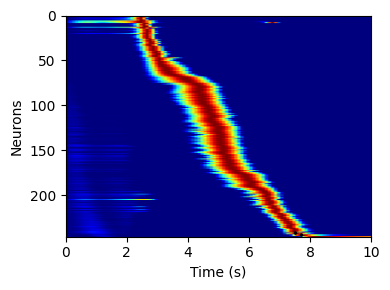

In [2]:
num_neuron = 512
trial = 0
load_data_type = f'2TS_vary{trial}'

data = np.load(f'../../data/{load_data_type}.npy', allow_pickle=True).item()
hidden_states = data[f'hidden_states_{num_neuron}']
avg_hs = np.mean(hidden_states, axis=0)
print(avg_hs.shape)

T = avg_hs.shape[0]
# --- First event --- #
# if trial == 0:
#     time_start, time_end = int(T * 0.25), int(T * 0.3)
# elif trial == 1:
#     time_start, time_end = int(T * 0.2),  int(T * 0.3)
# elif trial == 2:
#     time_start, time_end = int(T * 0.15), int(T * 0.35)
# elif trial == 3:
#     time_start, time_end = int(T * 0.1),  int(T * 0.4)
# elif trial == 4:
#     time_start, time_end = int(T * 0.05), int(T * 0.45)
# elif trial == 5:
#     time_start, time_end = int(T * 0),    int(T * 0.5)
# else:
#     raise ValueError(f"Invalid trial number: {trial}. Must be between 0 and 5.")

# --- Second event --- #
if trial == 0:
    time_start, time_end = int(T * 0.75), int(T * 0.8)
elif trial == 1:
    time_start, time_end = int(T * 0.7),  int(T * 0.8)
elif trial == 2:
    time_start, time_end = int(T * 0.65), int(T * 0.85)
elif trial == 3:
    time_start, time_end = int(T * 0.6),  int(T * 0.9)
elif trial == 4:
    time_start, time_end = int(T * 0.55), int(T * 0.95)
elif trial == 5:
    time_start, time_end = int(T * 0.5),  int(T * 1)
else:
    raise ValueError(f"Invalid trial number: {trial}. Must be between 0 and 5.")

# Plot the average hidden states
fig, ax = plt.subplots(figsize=(4, 3))
norm_hs, fig, ax = plt_hs(avg_hs, min_fr=0.1, fig=fig, ax=ax, time_start=time_start, time_end=time_end)
plt.tight_layout()
plt.xlabel('Time (s)')

# Get each neuron's max firing time
max_time_pts = np.argmax(norm_hs, axis=0)  

# Calculate the number of neurons with max firing time within the interval
num_in_interval = np.sum((max_time_pts >= time_start) & (max_time_pts <= time_end))
print('Num of time cells:', num_in_interval)
print('Interval length (s):', (time_end - time_start)/10)

In [2]:
num_time_cells = [133, 104, 96, 65, 46]
intervals = [4.0, 3.0, 2.0, 1.0, 0.5]

num_time_cells2 = [93, 72, 39, 25, 14]
intervals2 = [4.0, 3.0, 2.0, 1.0, 0.5]

Correlation coefficient: 0.98
Correlation coefficient 2: 0.99


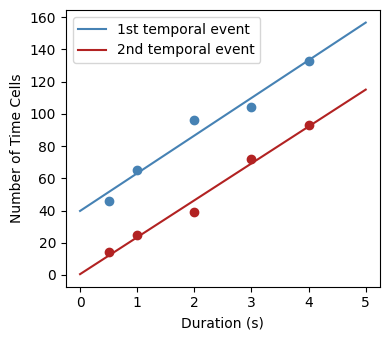

In [ ]:
# Do a linear fit
def linear(x, m, b):
    return m * x + b
from scipy.optimize import curve_fit
popt, pcov = curve_fit(linear, intervals, num_time_cells)
x_fit = np.linspace(0, 5, 100)
y_fit = linear(x_fit, *popt)
popt2, pcov2 = curve_fit(linear, intervals2, num_time_cells2)
x_fit2 = np.linspace(0, 5, 100)
y_fit2 = linear(x_fit2, *popt2)

# Calculate the correlation coefficient using seaborn
import seaborn as sns
fig, ax = plt.subplots(figsize=(4, 3.5))

correlation_matrix = np.corrcoef(intervals, num_time_cells)
correlation_coefficient = correlation_matrix[0, 1]
print(f'Correlation coefficient: {correlation_coefficient:.2f}')
# sns.regplot(x=intervals, y=num_time_cells, ci=95, scatter=False, 
#             line_kws={"color": 'steelblue', "label":f'corr={correlation_coefficient:.2f}'},
#             label=r'corr={:.2f}'.format(correlation_coefficient))
corr_m2 = np.corrcoef(intervals2, num_time_cells2)
corr_coef2 = corr_m2[0, 1]
print(f'Correlation coefficient 2: {corr_coef2:.2f}')
# sns.regplot(x=intervals2, y=num_time_cells2, ci=95, scatter=False, 
#             line_kws={"color": 'orange', "label":f'corr={corr_coef2:.2f}'},
#             label=r'corr={:.2f}'.format(corr_coef2))

# Plot num_time_cells vs intervals

# plt.plot(x_fit, y_fit, color='#297270')
ax.scatter(intervals, num_time_cells, marker='o', color='steelblue')
ax.plot(x_fit, y_fit, color='steelblue', label='1st temporal event')
ax.scatter(intervals2, num_time_cells2, marker='o', color='firebrick')
ax.plot(x_fit2, y_fit2, color='firebrick', label='2nd temporal event')

ax.set_xlabel('Duration (s)')
ax.set_ylabel('Number of Time Cells')
plt.legend()
plt.tight_layout()
plt.savefig('fig4_time_cell_corr_events', transparent=False, dpi=500)